mv: cannot stat 'sta-f-83.crs': No such file or directory
mv: cannot stat 'sta-f-83.stu': No such file or directory


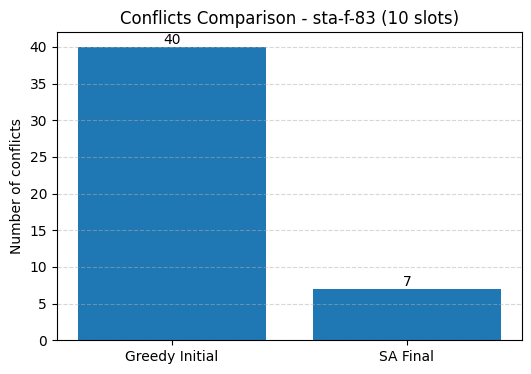

[RESULT] Dataset: sta-f-83 | Slots: 10 | Initial(Greedy): 40 | Final(SA): 7 | Time: 5.8s


In [3]:
# ---------------------------
# Setup (files location)
# ---------------------------
!mkdir -p datasets
!mv sta-f-83.crs datasets/
!mv sta-f-83.stu datasets/

"""
Exam Timetabling (Toronto Benchmark) — sta-f-83
Simulated Annealing (SA) with:
- Greedy initial solution
- Incremental conflict updates (O(deg(exam)) per move)
- Two neighborhoods: MOVE and SWAP
- Bias selection toward currently conflicted exams
- Multi-start (several runs with different seeds)

Representation:
    sol[exam] = timeslot   (timeslot is an integer in [0, max_slots-1])

Objective:
    Minimize the number of conflicting pairs placed in the same timeslot.
    A conflict exists between exams a and b if at least one student takes both.

Notes:
- This implementation minimizes "hard conflicts" (same-slot conflicts),
  not soft penalties (e.g., proximity costs) used in some timetabling variants.
"""

import time
import math
import random
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# 1) DATA LOADING
# ---------------------------------------------------------------------
def load_crs(path):
    """
    Read .crs file:
        Each line:  exam_id  something_else
    We store exams in a dict:
        exams[exam_id] = value  (the value is not used in optimization here,
                                 but we keep it in case you need it later)
    """
    exams = {}
    with open(path, "r") as f:
        for line in f:
            p = line.strip().split()
            if len(p) == 2:
                exams[int(p[0])] = int(p[1])
    return exams


def load_stu(path):
    """
    Read .stu file:
        Each line = one student, listing exam ids taken by that student.
    Output:
        students = [ [e1, e2, ...], [e7, e3, ...], ... ]
    """
    students = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                students.append(list(map(int, line.split())))
    return students


# ---------------------------------------------------------------------
# 2) BUILD CONFLICT GRAPH
# ---------------------------------------------------------------------
def build_conflict_graph(students):
    """
    Build an undirected conflict graph g:
        g[a] contains all exams that conflict with exam a.

    For each student with exams [x, y, z], we add conflicts:
        (x,y), (x,z), (y,z)  => complete clique among that student's exams.

    Implementation detail:
        combinations(exam_list, 2) enumerates all unordered pairs.
    """
    g = defaultdict(set)
    for exam_list in students:
        for a, b in combinations(exam_list, 2):
            g[a].add(b)
            g[b].add(a)
    return g


# ---------------------------------------------------------------------
# 3) GREEDY INITIAL SOLUTION
# ---------------------------------------------------------------------
def greedy_initial_solution(exams_list, g, max_slots):
    """
    Construct an initial solution greedily.

    Strategy:
    - Order exams by decreasing degree (most constrained first)
    - For each exam e, try each slot s and count conflicts with already placed neighbors
    - Choose the slot that minimizes immediate conflicts

    Output:
        sol: dict {exam: slot}
    """
    order = sorted(exams_list, key=lambda e: len(g.get(e, set())), reverse=True)

    sol = {}
    for e in order:
        best_slot = 0
        best_conf = None

        for s in range(max_slots):
            conf = 0
            for nb in g.get(e, ()):
                if nb in sol and sol[nb] == s:
                    conf += 1

            if best_conf is None or conf < best_conf:
                best_conf = conf
                best_slot = s
                if best_conf == 0:
                    break

        sol[e] = best_slot

    return sol


# ---------------------------------------------------------------------
# 4) INCREMENTAL COST STRUCTURE (cc)
# ---------------------------------------------------------------------
def init_conflict_counts(exams_list, sol, g):
    """
    Build cc = conflict counts per exam.

    Definition:
        cc[e] = number of neighbors nb of e such that sol[e] == sol[nb]

    We count each conflicting pair (e, nb) once using condition (e < nb),
    then we update cc for both endpoints.
    """
    cc = {e: 0 for e in exams_list}

    for e in exams_list:
        se = sol[e]
        for nb in g.get(e, ()):
            if e < nb and se == sol[nb]:
                cc[e] += 1
                cc[nb] += 1

    return cc


def total_conflicts_from_cc(cc):
    """
    Total conflicts = number of conflicting pairs in the timetable.

    Each conflicting pair is counted twice in cc:
        once in cc[a] and once in cc[b]
    So:
        total = sum(cc.values()) // 2
    """
    return sum(cc.values()) // 2


# ---------------------------------------------------------------------
# 5) LOCAL DELTA AND LOCAL UPDATES (MOVE / SWAP)
# ---------------------------------------------------------------------
def delta_cost_move(sol, g, exam, old_slot, new_slot):
    """
    Compute delta cost (new_cost - old_cost) if we move `exam`
    from old_slot to new_slot, while all other exams stay fixed.
    """
    d = 0
    for nb in g.get(exam, ()):
        if sol[nb] == old_slot:
            d -= 1
        if sol[nb] == new_slot:
            d += 1
    return d


def apply_move_update(sol, cc, g, exam, old_slot, new_slot):
    """
    Apply the move exam: old_slot -> new_slot AND update cc incrementally.
    """
    for nb in g.get(exam, ()):
        snb = sol[nb]

        if snb == old_slot:
            cc[exam] -= 1
            cc[nb] -= 1

        if snb == new_slot:
            cc[exam] += 1
            cc[nb] += 1

    sol[exam] = new_slot


def apply_swap_update(sol, cc, g, a, b):
    """
    Swap timeslots of exams a and b, updating cc incrementally.
    Returns total delta in conflicts.
    """
    sa = sol[a]
    sb = sol[b]
    if sa == sb:
        return 0

    d1 = delta_cost_move(sol, g, a, sa, sb)
    apply_move_update(sol, cc, g, a, sa, sb)

    d2 = delta_cost_move(sol, g, b, sb, sa)
    apply_move_update(sol, cc, g, b, sb, sa)

    return d1 + d2


# ---------------------------------------------------------------------
# 6) SIMULATED ANNEALING (SA) WITH CONFLICTED BIAS + MOVE/SWAP
# ---------------------------------------------------------------------
def simulated_annealing_fast(
    exams_list,
    g,
    max_slots,
    iters=60000,
    alpha=0.9995,
    seed=42,
    pick_conflicted_prob=0.85,
    T0=10.0,
    swap_prob=0.10,
):
    """
    Simulated Annealing to minimize conflicts.
    Returns:
    - best_sol: best timetable found
    - best_cost: number of conflicts in best_sol
    """
    random.seed(seed)

    sol = greedy_initial_solution(exams_list, g, max_slots)
    cc = init_conflict_counts(exams_list, sol, g)

    cur_cost = total_conflicts_from_cc(cc)
    best_cost = cur_cost
    best_sol = dict(sol)

    conflicted = {e for e in exams_list if cc[e] > 0}

    T = T0
    exams_tuple = tuple(exams_list)

    for _ in range(iters):
        if best_cost == 0:
            break

        use_conf = bool(conflicted) and (random.random() < pick_conflicted_prob)

        if random.random() < swap_prob and len(exams_tuple) >= 2:
            # SWAP
            a = random.choice(tuple(conflicted)) if use_conf else random.choice(exams_tuple)
            b = random.choice(exams_tuple)
            if a == b:
                continue

            old_cost = cur_cost
            d = apply_swap_update(sol, cc, g, a, b)
            new_cost = old_cost + d

            accept = (d <= 0) or (T > 1e-12 and random.random() < math.exp(-d / T))

            if accept:
                cur_cost = new_cost
                if cur_cost < best_cost:
                    best_cost = cur_cost
                    best_sol = dict(sol)
            else:
                # revert swap
                apply_swap_update(sol, cc, g, a, b)
                cur_cost = old_cost

            # update conflicted set (local)
            for x in (a, b):
                if cc[x] > 0:
                    conflicted.add(x)
                else:
                    conflicted.discard(x)

                for nb in g.get(x, ()):
                    if cc[nb] > 0:
                        conflicted.add(nb)
                    else:
                        conflicted.discard(nb)

        else:
            # MOVE
            exam = random.choice(tuple(conflicted)) if use_conf else random.choice(exams_tuple)

            old_slot = sol[exam]
            new_slot = random.randrange(max_slots)
            if new_slot == old_slot:
                continue

            d = delta_cost_move(sol, g, exam, old_slot, new_slot)

            if d <= 0 or (T > 1e-12 and random.random() < math.exp(-d / T)):
                apply_move_update(sol, cc, g, exam, old_slot, new_slot)
                cur_cost += d

                # update conflicted set (local)
                if cc[exam] > 0:
                    conflicted.add(exam)
                else:
                    conflicted.discard(exam)

                for nb in g.get(exam, ()):
                    if cc[nb] > 0:
                        conflicted.add(nb)
                    else:
                        conflicted.discard(nb)

                if cur_cost < best_cost:
                    best_cost = cur_cost
                    best_sol = dict(sol)

        T *= alpha
        if T < 1e-6:
            T = 1e-6

    return best_sol, best_cost


# ---------------------------------------------------------------------
# 7) MULTI-START (SEVERAL RUNS WITH DIFFERENT SEEDS)
# ---------------------------------------------------------------------
def multi_start_sa(
    exams_list,
    g,
    max_slots,
    runs=8,
    iters=60000,
    base_seed=100,
    alpha=0.9995,
    T0=10.0,
    pick_conflicted_prob=0.85,
    swap_prob=0.10,
):
    """
    Run SA multiple times with different random seeds and keep the best result.
    """
    best_overall = None
    best_cost = None

    for r in range(runs):
        seed = base_seed + r
        sol, c = simulated_annealing_fast(
            exams_list, g, max_slots,
            iters=iters, alpha=alpha, seed=seed,
            pick_conflicted_prob=pick_conflicted_prob,
            T0=T0,
            swap_prob=swap_prob
        )

        if best_cost is None or c < best_cost:
            best_cost = c
            best_overall = sol

    return best_overall, best_cost


# ---------------------------------------------------------------------
# 8) END-TO-END RUN FOR sta-f-83 + SMALL GRAPH
# ---------------------------------------------------------------------
def run_sta(max_slots):
    DATASET = "sta-f-83"
    exams = load_crs(f"datasets/{DATASET}.crs")
    students = load_stu(f"datasets/{DATASET}.stu")
    g = build_conflict_graph(students)
    exams_list = sorted(exams.keys())

    # Initial solution cost
    init_sol = greedy_initial_solution(exams_list, g, max_slots)
    init_cc = init_conflict_counts(exams_list, init_sol, g)
    init_cost = total_conflicts_from_cc(init_cc)

    start = time.time()

    _, best_conf = multi_start_sa(
        exams_list, g, max_slots,
        runs=8, iters=60000, base_seed=100,
        alpha=0.9995, T0=10.0,
        pick_conflicted_prob=0.85, swap_prob=0.10
    )

    elapsed = time.time() - start

    # ---- Small graph: Greedy vs SA conflicts (no change to the algorithm) ----
    plt.figure(figsize=(6, 4))
    bars = plt.bar(["Greedy Initial", "SA Final"], [init_cost, best_conf])
    plt.title(f"Conflicts Comparison - {DATASET} ({max_slots} slots)")
    plt.ylabel("Number of conflicts")
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    # show values above bars
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom")

    plt.show()

    print(
        f"[RESULT] Dataset: {DATASET} | Slots: {max_slots} | "
        f"Initial(Greedy): {init_cost} | Final(SA): {best_conf} | Time: {elapsed:.1f}s"
    )


if __name__ == "__main__":
    # Run only for 5 slots (as you requested)
    for s in [10]:
        run_sta(s)